In [1]:
from datasets import load_from_disk
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt

/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
npz_path = {}
npz_path[3] = f"/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_0_epoch.npz"

In [3]:
loaded = {}
for k, path in npz_path.items():
    print(f"\nloading key={k} from {path}")
    loaded[k] = np.load(path)
    print("  contained arrays:", loaded[k].files)
    for name in loaded[k].files:
        arr = loaded[k][name]
        print(f"    {name}: shape {arr.shape}, dtype {arr.dtype}")


loading key=3 from /home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_0_epoch.npz
  contained arrays: ['train', 'train_labels', 'valid', 'valid_labels', 'test', 'test_labels', 'n_distractors']
    train: shape (118287, 4, 1000), dtype float64
    train_labels: shape (118287,), dtype int64
    valid: shape (1500, 4, 1000), dtype float64
    valid_labels: shape (1500,), dtype int64
    test: shape (3500, 4, 1000), dtype float64
    test_labels: shape (3500,), dtype int64
    n_distractors: shape (), dtype int64


In [4]:
import numpy as np

def anchor_similarity_stats(X: np.ndarray, anchor_idx: np.ndarray):
    """
    X: shape (n_samples, n_images, n_features)
    anchor_idx: shape (n_samples,)
    
    Returns:
        mean_sim, std_sim
    """
    n_samples, n_images, _ = X.shape

    # Normalize features for cosine similarity
    X_norm = X / np.linalg.norm(X, axis=-1, keepdims=True)

    # Gather anchors: (n_samples, 1, n_features)
    anchors = X_norm[np.arange(n_samples), anchor_idx][:, None, :]

    # Cosine similarity with all images: (n_samples, n_images)
    sims = np.sum(anchors * X_norm, axis=-1)

    # Mask out anchors themselves
    mask = np.ones_like(sims, dtype=bool)
    mask[np.arange(n_samples), anchor_idx] = False

    sims = sims[mask]  # flattened over all distractors

    return sims.mean(), sims.std()

In [5]:
# anchor_similarity_stats(loaded[3]['train'], loaded[3]['train_labels'])

(np.float64(0.17297775727162837), np.float64(0.2138321648594406))

In [6]:
names =  ["/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_{num}_epoch.npz".format(num=i) for i in range(0,100,5)]
names

['/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_0_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_5_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_10_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_15_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_20_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_25_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_30_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_35_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_40_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_45_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distra

In [ ]:
names = []

In [7]:
data=(np.load(path) for path in names)

In [8]:
# len(list(data))

In [9]:
stats = [anchor_similarity_stats(d['train'], d['train_labels']) for d in tqdm(data)]
stats

20it [24:31, 73.57s/it]


[(np.float64(0.17297775727162837), np.float64(0.2138321648594406)),
 (np.float64(0.35776369664060703), np.float64(0.16511550702752026)),
 (np.float64(0.4248798049403878), np.float64(0.15159458761146644)),
 (np.float64(0.46407553316164607), np.float64(0.1439195053081446)),
 (np.float64(0.4910246705458155), np.float64(0.13880810305384222)),
 (np.float64(0.5115747257640111), np.float64(0.1347513704495621)),
 (np.float64(0.5279242144923633), np.float64(0.13150347457529257)),
 (np.float64(0.5413376447317275), np.float64(0.12940844130130227)),
 (np.float64(0.5530126824610835), np.float64(0.12702292197831022)),
 (np.float64(0.5625391432350727), np.float64(0.12520604952979353)),
 (np.float64(0.5712093719127549), np.float64(0.12372420562331254)),
 (np.float64(0.5786722986622889), np.float64(0.1225244951545818)),
 (np.float64(0.5854826896932418), np.float64(0.121380652119436)),
 (np.float64(0.5917467864241474), np.float64(0.12010323763060748)),
 (np.float64(0.5971024789590275), np.float64(0.1192

In [15]:
data2 = (np.load(path) for path in [
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_500_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_1000_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_5000_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_10000_epoch.npz'
])
stats_full = stats + [anchor_similarity_stats(d['train'], d['train_labels']) for d in tqdm(data2)]

4it [04:38, 69.60s/it]


In [16]:
stats_full

[(np.float64(0.17297775727162837), np.float64(0.2138321648594406)),
 (np.float64(0.35776369664060703), np.float64(0.16511550702752026)),
 (np.float64(0.4248798049403878), np.float64(0.15159458761146644)),
 (np.float64(0.46407553316164607), np.float64(0.1439195053081446)),
 (np.float64(0.4910246705458155), np.float64(0.13880810305384222)),
 (np.float64(0.5115747257640111), np.float64(0.1347513704495621)),
 (np.float64(0.5279242144923633), np.float64(0.13150347457529257)),
 (np.float64(0.5413376447317275), np.float64(0.12940844130130227)),
 (np.float64(0.5530126824610835), np.float64(0.12702292197831022)),
 (np.float64(0.5625391432350727), np.float64(0.12520604952979353)),
 (np.float64(0.5712093719127549), np.float64(0.12372420562331254)),
 (np.float64(0.5786722986622889), np.float64(0.1225244951545818)),
 (np.float64(0.5854826896932418), np.float64(0.121380652119436)),
 (np.float64(0.5917467864241474), np.float64(0.12010323763060748)),
 (np.float64(0.5971024789590275), np.float64(0.1192

In [11]:
# plt.plot(range(len(stats), [stat[0] for stat in stats]), label=)

In [18]:
def plot_stats(stats):
    """
    stats: list of (mean, std)
    """
    stats = np.array(stats)  # shape (n, 2)
    means = stats[:, 0]
    stds = stats[:, 1]

    x = np.arange(len(stats))*5

    plt.figure()
    plt.plot(x, means, label="Mean similarity")
    plt.fill_between(x, means - stds, means + stds, alpha=0.2)

    plt.title('Dependance of distractor-anchor similarity across epochs')
    plt.xlabel("Index")
    plt.ylabel("Similarity")
    plt.legend()
    plt.show()

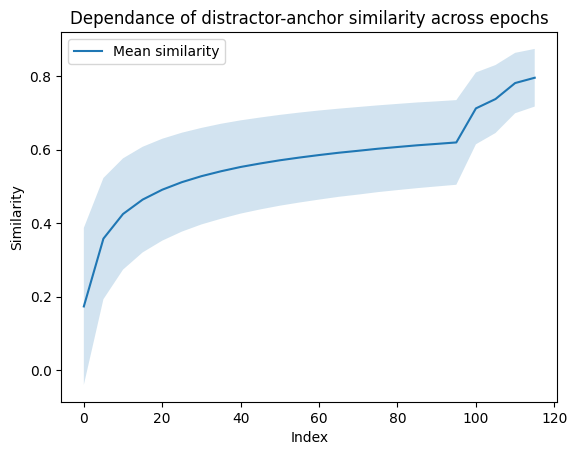

In [19]:
plot_stats(stats_full)

In [2]:
import numpy as np
from matplotlib import pyplot as plt
stats = [(np.float64(0.17297775727162837), np.float64(0.2138321648594406)),
 (np.float64(0.35776369664060703), np.float64(0.16511550702752026)),
 (np.float64(0.4248798049403878), np.float64(0.15159458761146644)),
 (np.float64(0.46407553316164607), np.float64(0.1439195053081446)),
 (np.float64(0.4910246705458155), np.float64(0.13880810305384222)),
 (np.float64(0.5115747257640111), np.float64(0.1347513704495621)),
 (np.float64(0.5279242144923633), np.float64(0.13150347457529257)),
 (np.float64(0.5413376447317275), np.float64(0.12940844130130227)),
 (np.float64(0.5530126824610835), np.float64(0.12702292197831022)),
 (np.float64(0.5625391432350727), np.float64(0.12520604952979353)),
 (np.float64(0.5712093719127549), np.float64(0.12372420562331254)),
 (np.float64(0.5786722986622889), np.float64(0.1225244951545818)),
 (np.float64(0.5854826896932418), np.float64(0.121380652119436)),
 (np.float64(0.5917467864241474), np.float64(0.12010323763060748)),
 (np.float64(0.5971024789590275), np.float64(0.11929694862344213)),
 (np.float64(0.6026705308384617), np.float64(0.11818423558864004)),
 (np.float64(0.6074077853865786), np.float64(0.11741691949918866)),
 (np.float64(0.6120148027617552), np.float64(0.11673460397476325)),
 (np.float64(0.6158632500355711), np.float64(0.11592262933777199)),
 (np.float64(0.6198370715473398), np.float64(0.11533091716049994)),
 (np.float64(0.7126372663294681), np.float64(0.09782881647339563)),
 (np.float64(0.7381126884767042), np.float64(0.09261179646733834)),
 (np.float64(0.7816478252983087), np.float64(0.0823169783329183)),
 (np.float64(0.7961015689684732), np.float64(0.07852930491280516))]

In [5]:
names =  ["/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_{num}_epoch.npz".format(num=i) for i in range(0,100,5)]
names += [  '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_500_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_1000_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_5000_epoch.npz',
 '/home/elena/emcomm/emcomm_captions/epoch_datasets_slower/data_3_distractors_10000_epoch.npz'
]


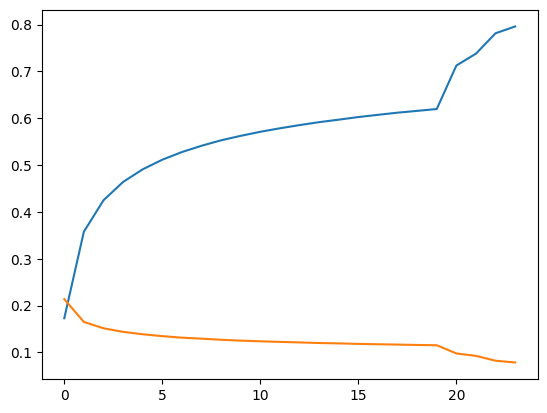

In [4]:
plt.plot([s[0] for s in stats], label='Similarity')
plt.plot([s[1] for s in stats], label='Std')

In [6]:
import re

result = []

for path, (avg, std) in zip(names, stats):
    epoch = int(re.search(r'_(\d+)_epoch\.npz$', path).group(1))
    result.append((epoch, float(avg), float(std)))

# optional: sort by epoch
result.sort(key=lambda x: x[0])

print(result)

[(0, 0.17297775727162837, 0.2138321648594406), (5, 0.35776369664060703, 0.16511550702752026), (10, 0.4248798049403878, 0.15159458761146644), (15, 0.46407553316164607, 0.1439195053081446), (20, 0.4910246705458155, 0.13880810305384222), (25, 0.5115747257640111, 0.1347513704495621), (30, 0.5279242144923633, 0.13150347457529257), (35, 0.5413376447317275, 0.12940844130130227), (40, 0.5530126824610835, 0.12702292197831022), (45, 0.5625391432350727, 0.12520604952979353), (50, 0.5712093719127549, 0.12372420562331254), (55, 0.5786722986622889, 0.1225244951545818), (60, 0.5854826896932418, 0.121380652119436), (65, 0.5917467864241474, 0.12010323763060748), (70, 0.5971024789590275, 0.11929694862344213), (75, 0.6026705308384617, 0.11818423558864004), (80, 0.6074077853865786, 0.11741691949918866), (85, 0.6120148027617552, 0.11673460397476325), (90, 0.6158632500355711, 0.11592262933777199), (95, 0.6198370715473398, 0.11533091716049994), (500, 0.7126372663294681, 0.09782881647339563), (1000, 0.7381126

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 300,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,

    "axes.titlesize": 11,
    "axes.labelsize": 10,

    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    "legend.fontsize": 9,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.7,

    "lines.linewidth": 1.5,

    "savefig.bbox": "tight",
})

Text(0, 0.5, 'Similarity')

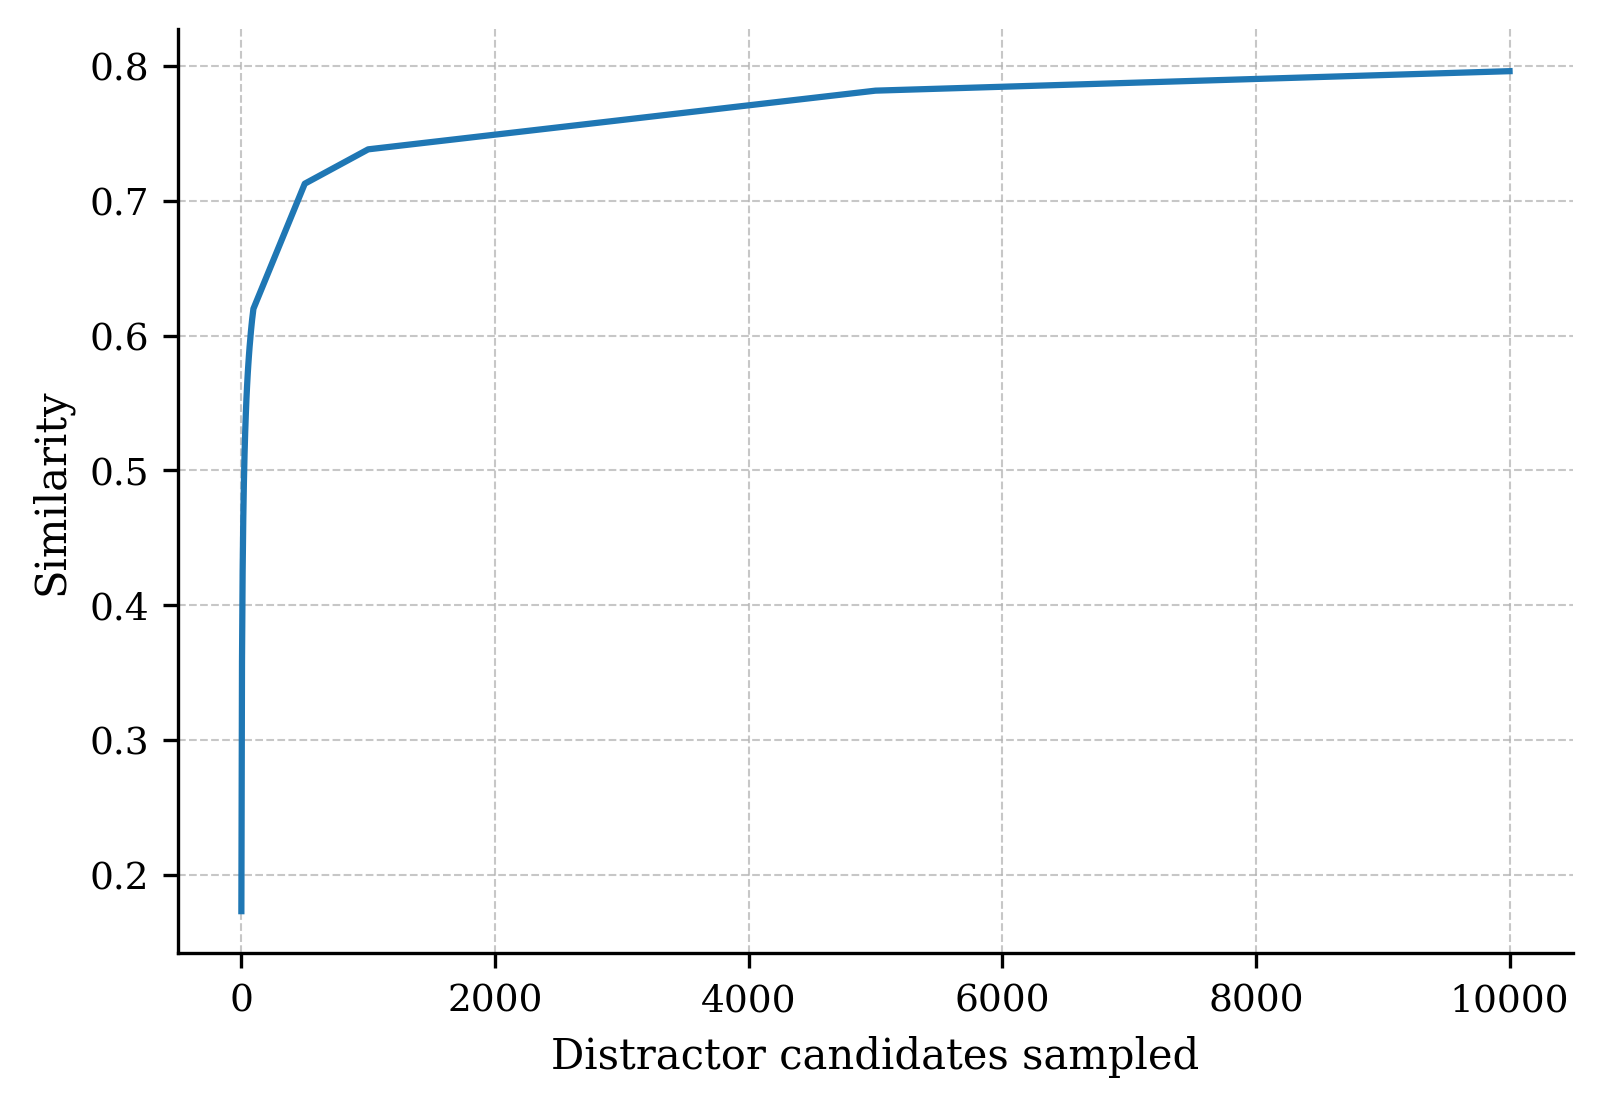

In [22]:
plt.plot([s[0] for s in result], [s[1] for s in result], label='Similarity')#, marker='o', markersize=4)
# plt.xscale('log')
plt.xlabel('Distractor candidates sampled')
plt.ylabel('Similarity')
# plt.title('Similarity of distractors to anchors across the number of distractor candidates')

In [23]:
curriculum = [0, 5, 10, 20, 30, 50, 60, 70, 80, 90] + [99]*7+[150]*8+[300]*9+[500]*10+[750]*11+[1000]*12+[1500]*13+[2000]*14+[3000]*15+[5000]*18+[7500]*22+[12000]*25


In [25]:
curriculum_sims = []
epoch2sim = {epoch: (avg, std) for epoch, avg, std in result}
for e in curriculum:
    if e in epoch2sim:
        avg, std = epoch2sim[e]
        curriculum_sims.append((e, avg, std))

In [26]:
curriculum_sims

[(0, 0.17297775727162837, 0.2138321648594406),
 (5, 0.35776369664060703, 0.16511550702752026),
 (10, 0.4248798049403878, 0.15159458761146644),
 (20, 0.4910246705458155, 0.13880810305384222),
 (30, 0.5279242144923633, 0.13150347457529257),
 (50, 0.5712093719127549, 0.12372420562331254),
 (60, 0.5854826896932418, 0.121380652119436),
 (70, 0.5971024789590275, 0.11929694862344213),
 (80, 0.6074077853865786, 0.11741691949918866),
 (90, 0.6158632500355711, 0.11592262933777199),
 (500, 0.7126372663294681, 0.09782881647339563),
 (500, 0.7126372663294681, 0.09782881647339563),
 (500, 0.7126372663294681, 0.09782881647339563),
 (500, 0.7126372663294681, 0.09782881647339563),
 (500, 0.7126372663294681, 0.09782881647339563),
 (500, 0.7126372663294681, 0.09782881647339563),
 (500, 0.7126372663294681, 0.09782881647339563),
 (500, 0.7126372663294681, 0.09782881647339563),
 (500, 0.7126372663294681, 0.09782881647339563),
 (500, 0.7126372663294681, 0.09782881647339563),
 (1000, 0.7381126884767042, 0.092